In [14]:
import pandas as pd


mbc = pd.read_csv('tmp/test.csv', usecols=range(6), index_col=False)
mbc = mbc.fillna('')

mbc

,Document,Speaker,ID,Particles,Bases,Fragment
0,mbc001,Hemana Waaka,mbc001.6.0.1995-04-06,e.ngā/o.te,matawaka/motu,E ngā matawaka o te motu
1,mbc001,Hemana Waaka,mbc001.6.1.1995-04-06,kia/,ora/koutou,kia ora anō rā koutou katoa.
2,mbc001,Hemana Waaka,mbc001.6.2.1995-04-06,/ā/mō,anei/tātou/wehenga/tēnei/ata,Anei rā ā tātou wehenga kōrero mō tēnei ata.
3,mbc001,Hemana Waaka,mbc001.8.0.1995-04-06,/i.te/o.te/o.te/o/ki.te/i,mai/tīmatanga/kuhu/rōpū/pōhutu/marae/whakarewa...,Mai i te tīmatanga o te kuhu atu o Te Rōpū o P...
4,mbc001,Hemana Waaka,mbc001.8.1.1995-04-06,//a.ngā/i,tērā/anō/ētahi/āwangawanga/kaumātua/roto-rua,tērā anō ētahi āwangawanga a ngā kaumātua rā i...
...,...,...,...,...,...,...
192333,mbc273,Wena Tait,mbc273.128.15.1995-10-17,,whitu,whitu
192334,mbc273,Wena Tait,mbc273.128.16.1995-10-17,,rima,rima.
192335,mbc273,Wena Tait,mbc273.128.17.1995-10-17,nō,reira,Nō reira
192336,mbc273,Wena Tait,mbc273.128.18.1995-10-17,ko//e,wena/tēnei/mihi,ko Wena [Tait] tēnei e mihi atu nei


In [15]:
df = pd.DataFrame(mbc[['ID', 'Particles', 'Fragment']])
df['Particles'] = df['Particles'].str.split('/').tolist()

df

,ID,Particles,Fragment
0,mbc001.6.0.1995-04-06,"[e.ngā, o.te]",E ngā matawaka o te motu
1,mbc001.6.1.1995-04-06,"[kia, ]",kia ora anō rā koutou katoa.
2,mbc001.6.2.1995-04-06,"[, ā, mō]",Anei rā ā tātou wehenga kōrero mō tēnei ata.
3,mbc001.8.0.1995-04-06,"[, i.te, o.te, o.te, o, ki.te, i]",Mai i te tīmatanga o te kuhu atu o Te Rōpū o P...
4,mbc001.8.1.1995-04-06,"[, , a.ngā, i]",tērā anō ētahi āwangawanga a ngā kaumātua rā i...
...,...,...,...
192333,mbc273.128.15.1995-10-17,[],whitu
192334,mbc273.128.16.1995-10-17,[],rima.
192335,mbc273.128.17.1995-10-17,[nō],Nō reira
192336,mbc273.128.18.1995-10-17,"[ko, , e]",ko Wena [Tait] tēnei e mihi atu nei


In [16]:
import numpy as np

values = pd.Series(np.concatenate(df['Particles']))
counts = values.groupby(values).count().sort_values(ascending=False).rank(method='first', ascending=False).astype(int) - 1

counts

            0
i           1
te          2
e           3
ā           4
         ... 
me.o      259
mā.ana    260
nā.aku    261
nā.wō     262
ō.ā       263
Length: 264, dtype: int64

In [17]:
import numpy as np


def update_matrix(mat, rank, utterance):
    for pair in zip(utterance, utterance[1:]):
        a, b = (rank[i] for i in pair)
        mat[a, b] += 1

mat = np.zeros((len(counts), len(counts)))
# df['Particles'].apply(lambda x: update_matrix(mat, counts, x))
update_matrix(mat, counts, values)

mat

array([[2.0858e+04, 6.2410e+03, 5.2540e+03, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.9060e+03, 4.5420e+03, 2.2100e+03, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [3.2250e+03, 1.8940e+03, 2.9060e+03, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]])

In [18]:
row_sum = np.sum(mat, axis=1)

for i, row in enumerate(row_sum):
    if not row:
        mat[i, i] = 1

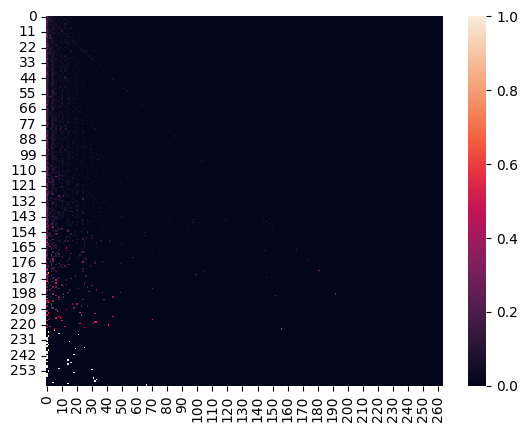

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


p = mat / np.sum(mat, axis=1).reshape(-1, 1)

# odds = np.log(p / (1 - p))

sns.heatmap(p)
plt.show()

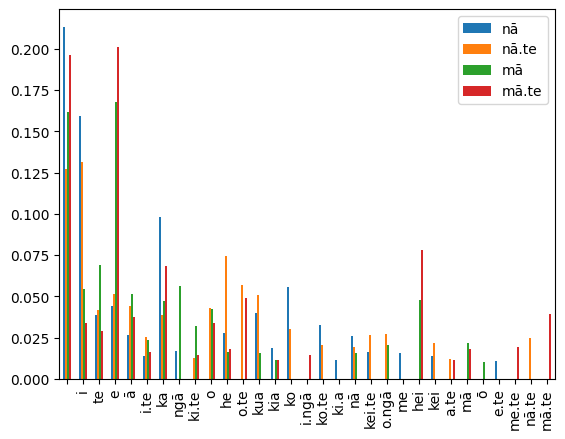

In [20]:
import matplotlib.pyplot as plt


def find(marker):
    return p[counts[marker], :]


columns = ['nā', 'nā.te', 'mā', 'mā.te']
comp = pd.DataFrame(zip(*(find(c) for c in columns)), index=counts.index, columns=columns)
comp[comp > 0.01].dropna(how='all').plot.bar()
plt.show()

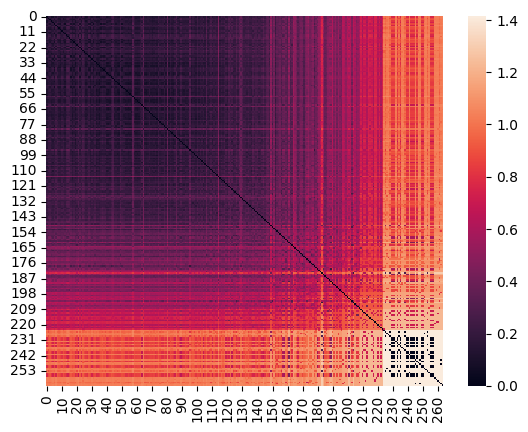

In [21]:
dmat = np.zeros(mat.shape)

for i in range(len(mat)):
    for j in range(len(mat)):
        dmat[i, j] = np.linalg.norm(p[i, :] - p[j, :])

sns.heatmap(dmat)
plt.show()

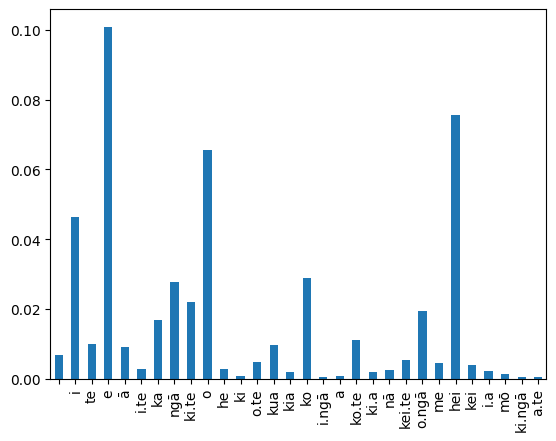

In [32]:
from scipy.special import kl_div


kl = kl_div(p[counts['mā'],:], p[counts['nā'],:])
pd.Series(kl, index=counts.index)[:30].plot.bar()
plt.show()

In [23]:
from sklearn.metrics import mutual_info_score


mutual_info_score(p[counts['nā'], :], p[counts['nā.te'], :])

/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


0.9266192360064145

In [24]:
from pydtmc import MarkovChain

mc = MarkovChain(p)

mc

MarkovChain

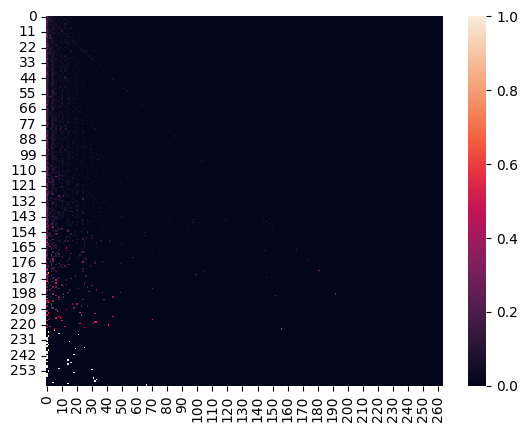

In [25]:
sns.heatmap(mc.to_matrix())
plt.show()

In [26]:
f = counts.apply(lambda x: mc.is_cyclic_state(x))
f[f]

          True
i         True
te        True
e         True
ā         True
          ... 
me.o      True
mā.ana    True
nā.aku    True
nā.wō     True
ō.ā       True
Length: 264, dtype: bool

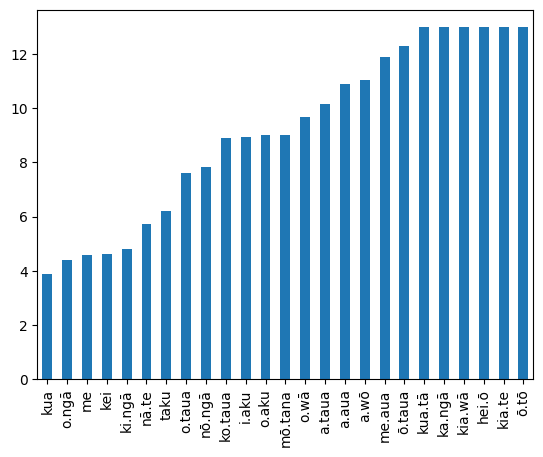

In [27]:
pd.Series(np.log(mc.mean_recurrence_times()), index=counts.index).sample(25).sort_values().plot.bar()
plt.show()

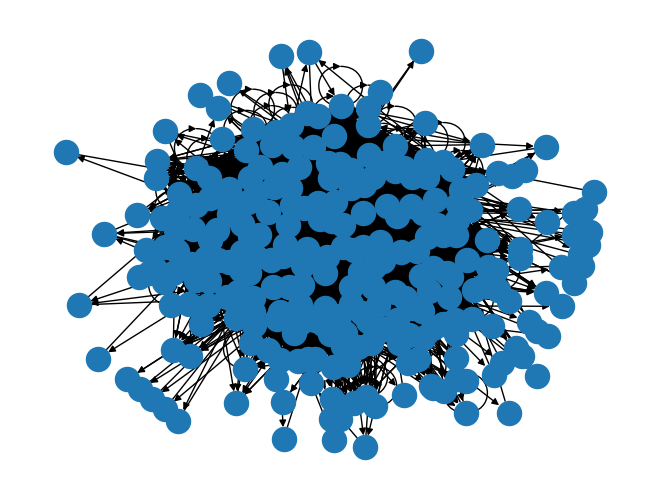

In [28]:
import networkx as nx


g = mc.to_graph()
nx.draw(g)

In [29]:
from networkx.drawing.nx_agraph import write_dot


write_dot(g, 'tmp/markov.dot')